<a href="https://colab.research.google.com/github/OJB-Quantum/MuMax3-How-To/blob/main/Python%20Code_MuMax3%20Data%20Plots/STT_Switching_Simulation_with_MuMax3_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

The following table defines the foundational parameters alongside their required SI units for the MuMax3 execution.

| Physical Parameter | Script Variable | Standard SI Unit | Unit Symbol |
| --- | --- | --- | --- |
| Spatial dimension | `sizeX`, `sizeY`, `sizeZ` | meters | m |
| Grid discretization | `Nx`, `Ny` | dimensionless | $N_x, N_y$ |
| Volume saturation magnetization | `Msat` | amperes per meter | A/m |
| Exchange stiffness constant | `Aex` | joules per meter | J/m |
| Gilbert damping constant | `alpha` | dimensionless | $\alpha$ |
| Normalized initial magnetization | `m` | dimensionless | $\mathbf{m}$ |
| Slonczewski asymmetry parameter | `lambda` | dimensionless | $\Lambda$ |
| Spin polarization fraction | `Pol` | dimensionless | $P$ |
| Secondary Slonczewski parameter | `epsilonprime` | dimensionless | $\epsilon'$ |
| In-plane geometrical angle | `angle` | degrees | ° |
| Fixed layer polarization vector | `fixedlayer`, `px`, `py` | dimensionless | $\mathbf{p}$ |
| Total electrical current | `Jtot` | amperes | A |
| Cross-sectional area | `area` | square meters | m² |
| Electrical current density | `jc`, `J` | amperes per square meter | A/m² |
| Integration time periods | `autosave`, `tableautosave`, `run` | seconds | s |

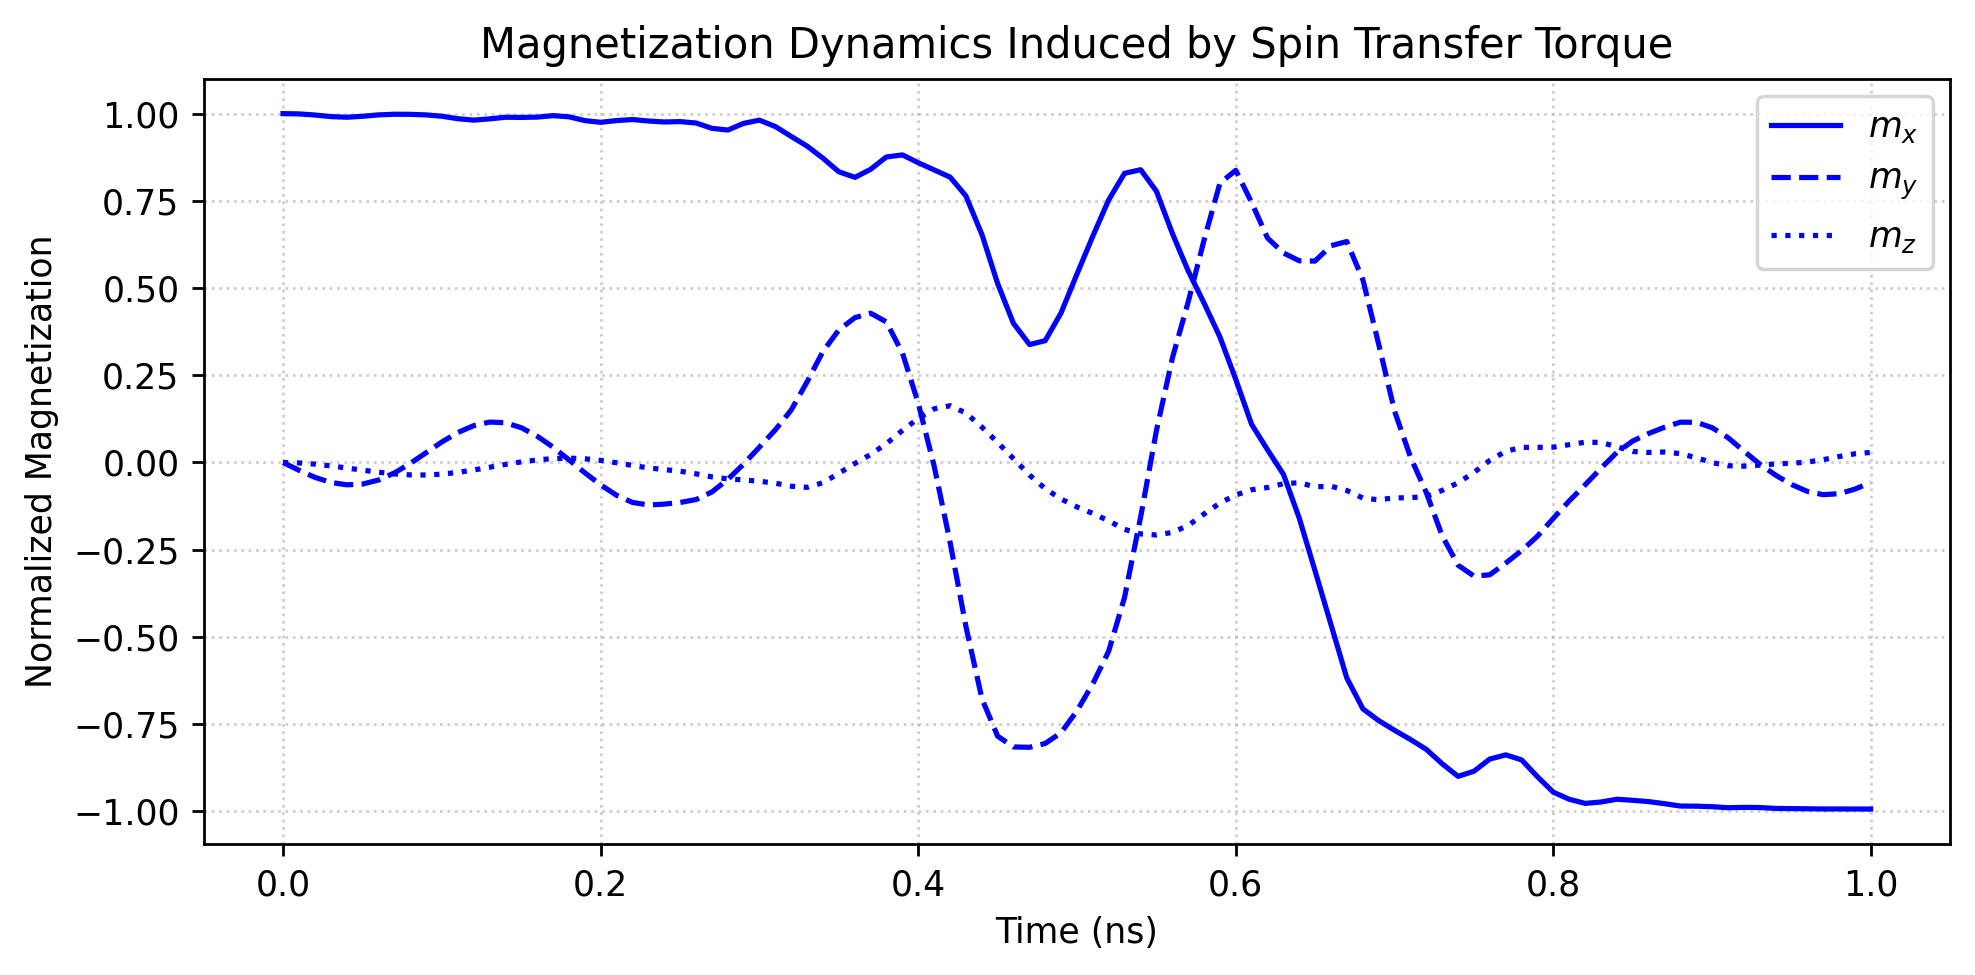

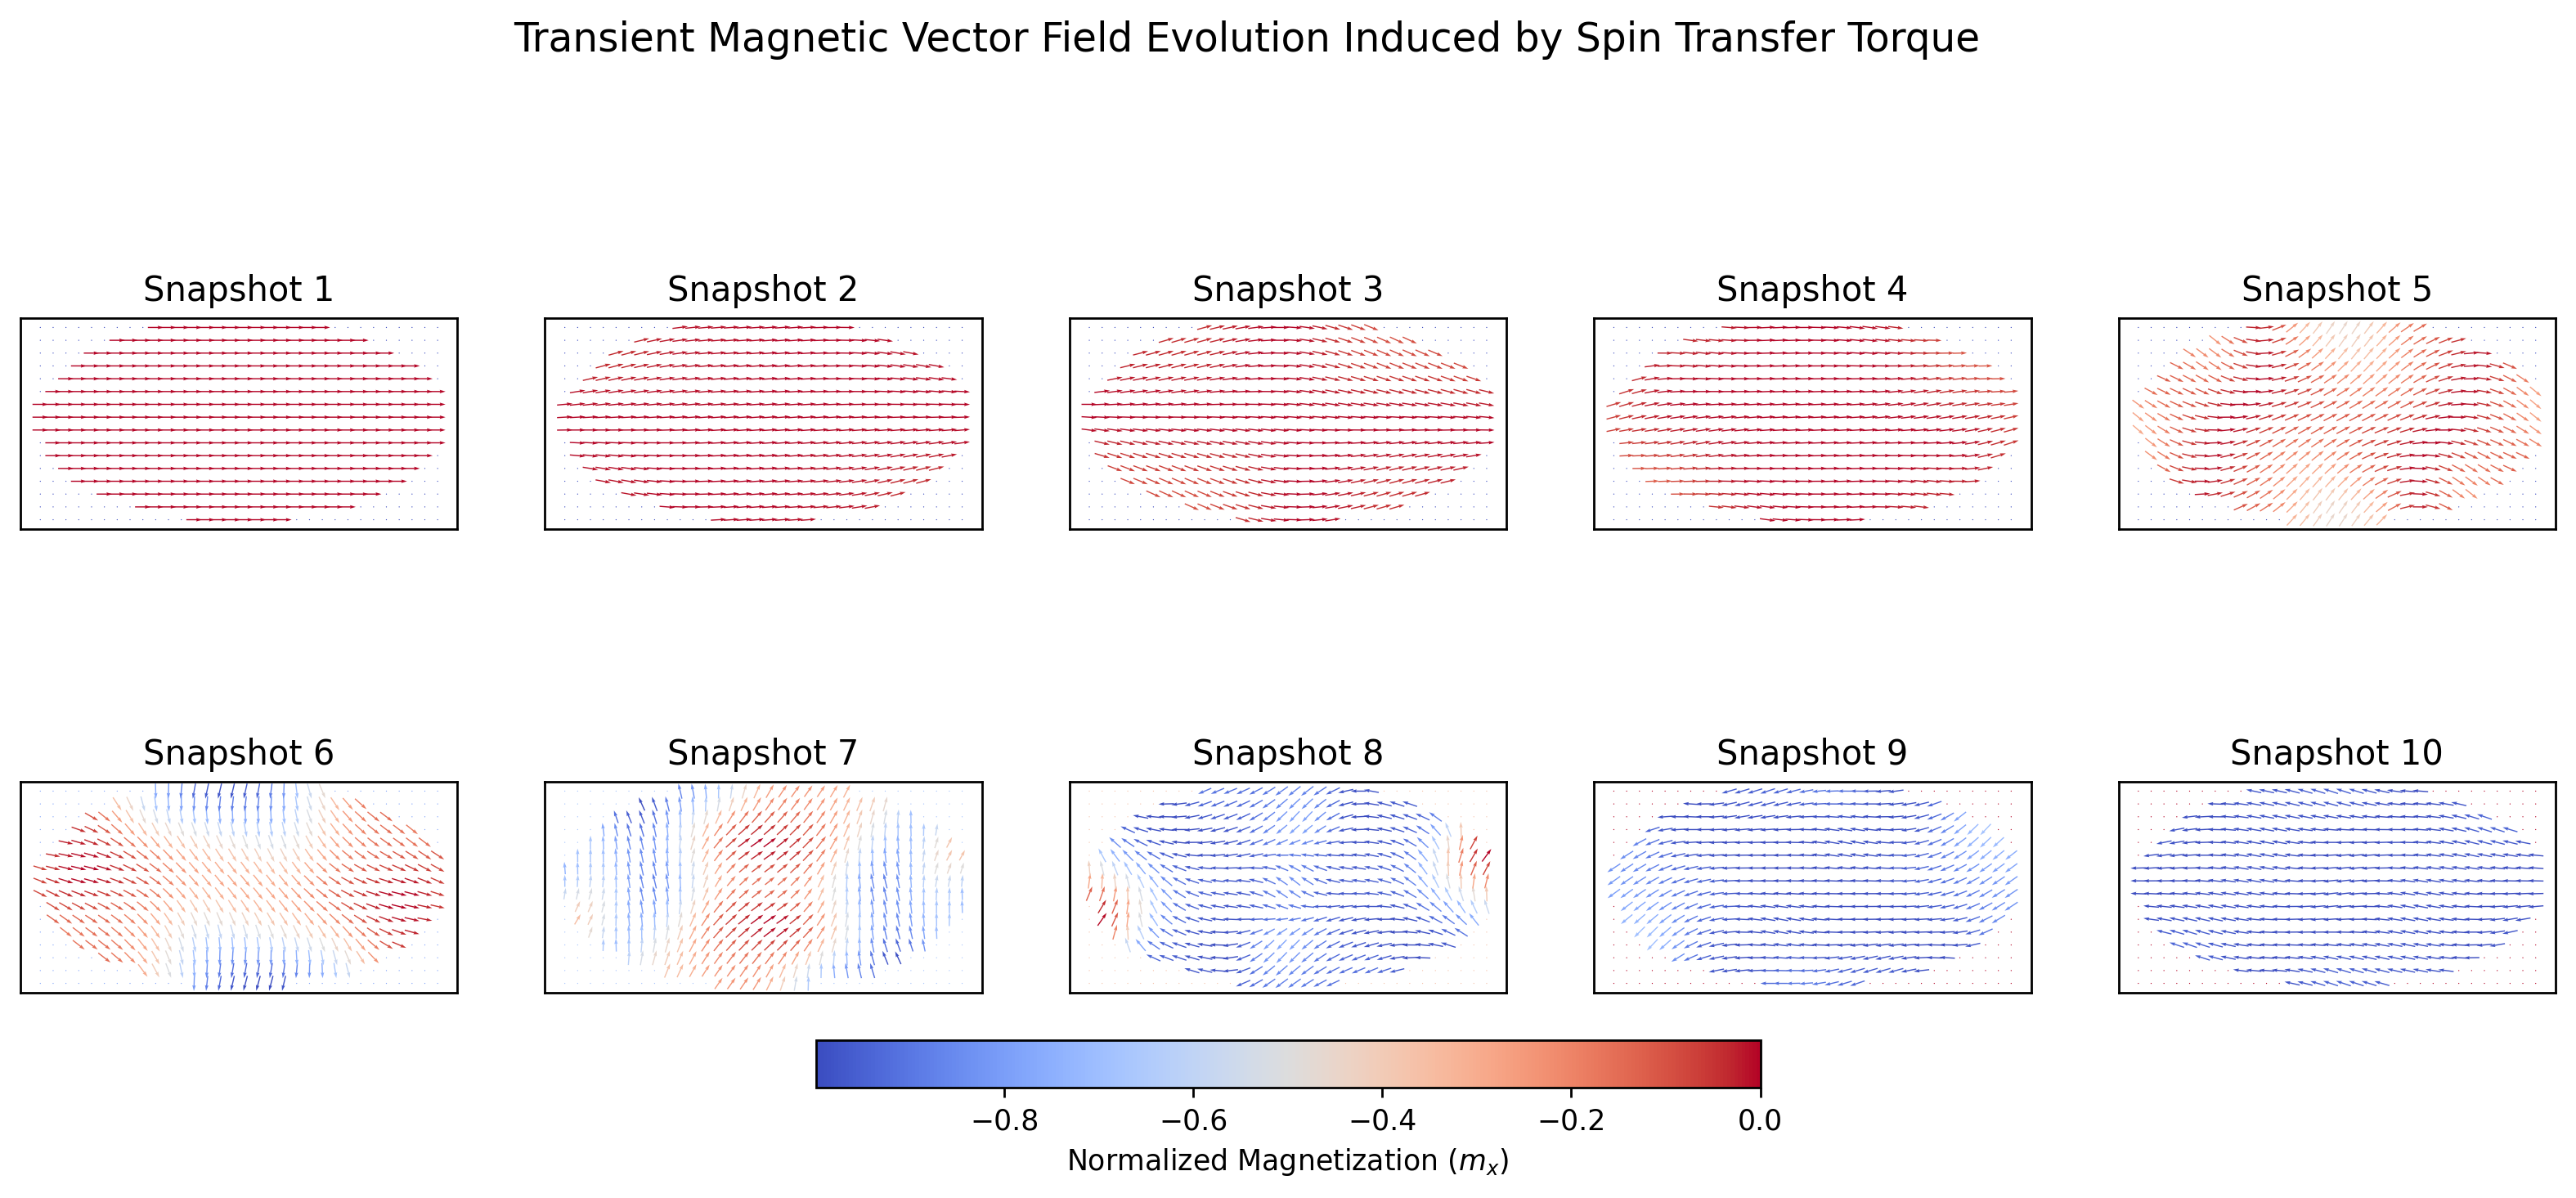

In [4]:
"""This script initializes the MuMax3 micromagnetic simulation environment, executes the numerical
integration, extracts the resulting magnetic vector fields, and visualizes the transient dynamics
alongside ten distinct spatial snapshots within a single unified process. The initial example material
used here is a permalloy free layer.
"""

import os
import subprocess
import sys
import glob

# ---------------------------------------------------
# Control Knobs
# ---------------------------------------------------
MUMAX_URL = "https://mumax.ugent.be/mumax3-binaries/mumax3.12_linux_cuda12.9.tar.gz"
ARCHIVE_NAME = "mumax3.12_linux_cuda12.9.tar.gz"
EXTRACTED_DIR = "mumax3.12_linux_cuda12.9"
TARGET_DIR = "mumax3.12"
SIMULATION_FILENAME = "stt_bit_cell.mx3"
RESULTS_DIRECTORY = "stt_bit_cell.out"
TABULAR_DATA_FILE = "table.txt"
FIGURE_RESOLUTION_DPI = 250
FONT_FAMILY_PREFERENCE = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT_PREFERENCE = 'normal'
SNAPSHOT_ROWS = 2
SNAPSHOT_COLUMNS = 5
MAX_SNAPSHOTS = 10
QUIVER_SUBSAMPLING_STEP = 2
QUIVER_ARROW_SCALE = 28.0
MAGNETIZATION_COLOR_DIRECTION = "M_X"  # Accepted variables: "M_X", "M_Y", or "M_Z"

# ---------------------------------------------------
# Environment Preparation
# ---------------------------------------------------
subprocess.run(["nvidia-smi", "--query-gpu=name,driver_version,compute_cap", "--format=csv"], check=True)
subprocess.run(["wget", "-q", MUMAX_URL], check=True)
subprocess.run(["tar", "-xvf", ARCHIVE_NAME], check=True)

if os.path.exists(ARCHIVE_NAME):
    os.remove(ARCHIVE_NAME)

if os.path.exists(TARGET_DIR):
    subprocess.run(["rm", "-rf", TARGET_DIR], check=True)

os.rename(EXTRACTED_DIR, TARGET_DIR)
os.environ["PATH"] += f":/content/{TARGET_DIR}"

# ---------------------------------------------------
# Simulation Configuration
# ---------------------------------------------------

'''The below parameters are for Permalloy (NiFe).
However, you can change the free layer terms to match the parameters of an existing magnetic tunnel junction (MTJ) free layer
or an existing spin torque oscillator (STO) free layer material you might be interested in, which are often found in published
articles or lectures. Keep in mind that MuMax3 defaults to using SI units.
'''

mx3_configuration = """
// geometry
sizeX := 160e-9
sizeY := 80e-9
sizeZ := 5e-9

Nx := 64
Ny := 32

setgridsize(Nx, Ny, 1)
setcellsize(sizeX/Nx, sizeY/Ny, sizeZ)
setGeom(ellipse(sizeX, sizeY))

// set up free layer
Msat  = 800e3 // This is the same thing as 8.0e5
Aex   = 13e-12
alpha = 0.01
m     = uniform(1, 0, 0)

// set up spacer layer parameters
lambda       = 1
Pol          = 0.5669
epsilonprime = 0

// set up fixed layer polarization
angle := 20
px := cos(angle * pi/180)
py := sin(angle * pi/180)
fixedlayer = vector(px, py, 0)

// send current or switching current for STT MTJs
Jtot := -0.008            // total current in A
area := sizeX*sizeY*pi/4
jc   := Jtot / area       // current density in A/m2
J = vector(0, 0, jc)

// schedule output & run
autosave(m, 100e-12)
tableautosave(10e-12)
run(1e-9)
"""

with open(SIMULATION_FILENAME, "w", encoding="utf-8") as file:
    file.write(mx3_configuration)

# ---------------------------------------------------
# Numerical Execution
# ---------------------------------------------------
subprocess.run(["mumax3", SIMULATION_FILENAME], check=True)

# ---------------------------------------------------
# Package Verification
# ---------------------------------------------------
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pandas", "matplotlib", "numpy"])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Matplotlib Parameters
# ---------------------------------------------------
plt.rcParams['figure.dpi'] = FIGURE_RESOLUTION_DPI
plt.rcParams['font.sans-serif'] = FONT_FAMILY_PREFERENCE
plt.rcParams['font.weight'] = FONT_WEIGHT_PREFERENCE

# ---------------------------------------------------
# Tabular Data Ingestion and Visualization
# ---------------------------------------------------
data_path = os.path.join(RESULTS_DIRECTORY, TABULAR_DATA_FILE)
simulation_data = pd.read_csv(data_path, sep='\t')

time_array = simulation_data['# t (s)'] * 1e9
mx_component = simulation_data['mx ()']
my_component = simulation_data['my ()']
mz_component = simulation_data['mz ()']

fig_timeseries, ax_timeseries = plt.subplots(figsize=(8, 4))
ax_timeseries.plot(time_array, mx_component, label=r'$m_x$', color='#0000FF', linestyle='solid', linewidth=1.5)
ax_timeseries.plot(time_array, my_component, label=r'$m_y$', color='#0000FF', linestyle='dashed', linewidth=1.5)
ax_timeseries.plot(time_array, mz_component, label=r'$m_z$', color='#0000FF', linestyle='dotted', linewidth=1.5)

ax_timeseries.set_xlabel('Time (ns)')
ax_timeseries.set_ylabel('Normalized Magnetization')
ax_timeseries.set_title('Magnetization Dynamics Induced by Spin Transfer Torque')
ax_timeseries.legend(loc='upper right', frameon=True)
ax_timeseries.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Vector Field Conversion and Ingestion
# ---------------------------------------------------
ovf_files = sorted(glob.glob(os.path.join(RESULTS_DIRECTORY, "*.ovf")))
ovf_files = ovf_files[:MAX_SNAPSHOTS]

for ovf_file in ovf_files:
    subprocess.run(["mumax3-convert", "-numpy", ovf_file], check=True)

npy_files = sorted(glob.glob(os.path.join(RESULTS_DIRECTORY, "*.npy")))
npy_files = npy_files[:MAX_SNAPSHOTS]

# ---------------------------------------------------
# Vector Field Visualization
# ---------------------------------------------------
fig_vectors, axes = plt.subplots(SNAPSHOT_ROWS, SNAPSHOT_COLUMNS, figsize=(16, 6))
axes_flat = axes.flatten()

if MAGNETIZATION_COLOR_DIRECTION == "M_X":
    colorbar_label = r'Normalized Magnetization ($m_x$)'
elif MAGNETIZATION_COLOR_DIRECTION == "M_Y":
    colorbar_label = r'Normalized Magnetization ($m_y$)'
elif MAGNETIZATION_COLOR_DIRECTION == "M_Z":
    colorbar_label = r'Normalized Magnetization ($m_z$)'
else:
    colorbar_label = r'Normalized Magnetization ($m_x$)'

for index, npy_file in enumerate(npy_files):
    vector_data = np.load(npy_file)

    mx_grid = vector_data[0, 0, :, :]
    my_grid = vector_data[1, 0, :, :]
    mz_grid = vector_data[2, 0, :, :]

    if MAGNETIZATION_COLOR_DIRECTION == "M_X":
        color_grid = mx_grid
    elif MAGNETIZATION_COLOR_DIRECTION == "M_Y":
        color_grid = my_grid
    elif MAGNETIZATION_COLOR_DIRECTION == "M_Z":
        color_grid = mz_grid
    else:
        color_grid = mx_grid

    ny_points, nx_points = mx_grid.shape
    x_coordinates, y_coordinates = np.meshgrid(np.arange(nx_points), np.arange(ny_points))

    ax = axes_flat[index]

    slice_y = slice(0, ny_points, QUIVER_SUBSAMPLING_STEP)
    slice_x = slice(0, nx_points, QUIVER_SUBSAMPLING_STEP)

    quiver_plot = ax.quiver(
        x_coordinates[slice_y, slice_x],
        y_coordinates[slice_y, slice_x],
        mx_grid[slice_y, slice_x],
        my_grid[slice_y, slice_x],
        color_grid[slice_y, slice_x],
        cmap='coolwarm',
        pivot='mid',
        scale=QUIVER_ARROW_SCALE
    )

    ax.set_title(f'Snapshot {index + 1}')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

cbar = fig_vectors.colorbar(quiver_plot, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.05, pad=0.05)
cbar.set_label(colorbar_label)
fig_vectors.suptitle('Transient Magnetic Vector Field Evolution Induced by Spin Transfer Torque', fontsize=14)

plt.show()